In [218]:
import random
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Tools

In [377]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data 
        self._prev = set(_children) # the children that make up this value
        self._op = _op # operation that make up this value
        self.label = label
        self.grad = 0.0 # gradient = 0 implies changing this variable does not change the loss function
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    # addition
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        # this function should propogate the grad from output to self and other
        # for addition, this is just a factor of 1x (distribute values)
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward 
        
        return out

    def __radd__(self, other):
        return self + other

    # multiplication
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        # for multiplication, grad = other term's value * parent's grad
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other): # other * self, i.e. 2 * Value(3)
        return self * other

    # division
    def __truediv__(self, other): # self / other
        return self * other ** -1

    def __rtruediv__(self, other):
        return self / other

    # subtraction
    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return self - other

    def __neg__(self):
        return self * -1

    def __pow__(self, other): 
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self, ), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        
        return out 

    def exp(self):
        x = self.data
        out = Value(np.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data 
        t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t ** 2) * out.grad # out.grad is just deriv of itself which is 1
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
              visited.add(v)
              for child in v._prev:
                  build_topo(child)
              topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
          node._backward()

In [216]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    # visualize a node
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # create a node for every value in the graph
        dot.node(name=uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # create an operation node if this value is a result of any operations
            dot.node(name = uid + n._op, label = n._op)
            # connect the node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## 2. Manual Propogation #1

Forward pass with `Value`:

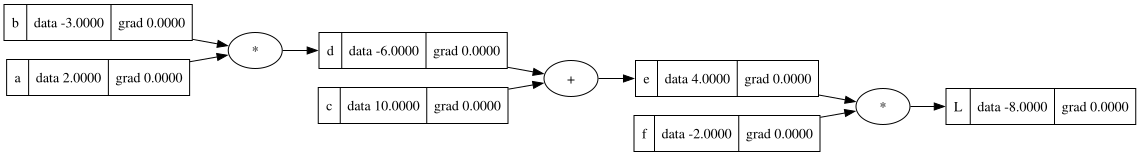

In [349]:
# leaf nodes
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

# parent nodes
e = 0; d = 0

def forward_pass(a, b, c, f, adj):
    # adj is the adjustment for each input
    global e, d

    # adjust the leaf nodes/inputs
    for i, node in enumerate([a, b, c, f]):
        node.data += adj[i]

    d = a * b; d.label = 'd'
    e = d + c; e.label = 'e'
    L = e * f; L.label = 'L'
    return L

L = forward_pass(a, b, c, f, [0.0] * 4)
draw_dot(L)

To understand the backward propogation, we define a property `gradient`, the impact of the current node on the output **(positive or negative)**, which is simply the derivative. 

For the first multiplication (impact of $e$ on $L$), we are interested in finding $\frac{dL}{de}$:
$$L = e * f$$
$$\frac{dL}{de} = f = -2.0$$

From this, we can see that the gradient of a term in a multiplication operation is simply the value of the other term. 

For addition (impact of $d$ on $L$), we are interested in finding $\frac{dL}{dd}$:
$$\begin{align*}
\frac{dL}{dd} &= \frac{dL}{de} \cdot \frac{de}{dd} \\
&= -2.0 \cdot 1.0 \\
&= -2.0
\end{align*}$$

From this, we can see that an addition operation always has a local derivative of $1$, hence we can think of `+` as simply distributing the derivative from the parent node to the child nodes.

Lastly, we want to find $\frac{dL}{da}$, the impact of $a$ on $L$:
$$\begin{align*}
\frac{dL}{da} &= \frac{dL}{dd} \cdot \frac{dd}{da} \\
&= -2.0 \cdot -3.0 \\
&= 6.0
\end{align*}$$

As such, through backward propogation, we can derive the gradient on each input, then the goal becomes tweaking the inputs to increase the result output $L$. 

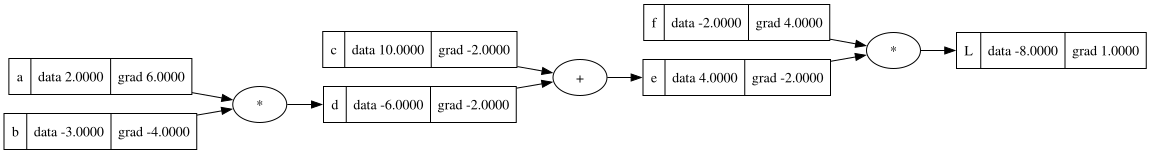

In [22]:
# fill in the gradient values
L.grad = 1.0
e.grad = -2.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

draw_dot(L)

Now let's try to increase the value of $L$ by nudging the value of the leaf nodes in the direction of the gradient. 

This essentially represents one optimization step.  

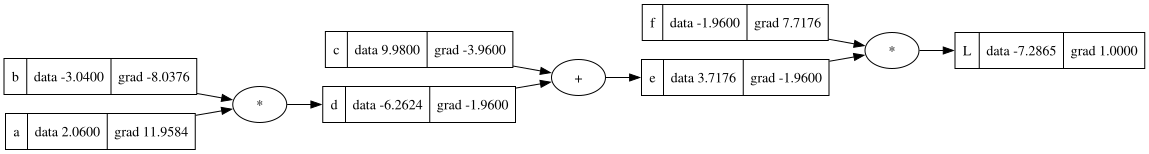

In [350]:
def step():
    global L
    adj = [0.01 * node.grad for node in [a, b, c, f]]
    L = forward_pass(a, b, c, f, adj)
    L.backward()
    
# backward propogation
step()
step()

draw_dot(L)

## 3. Manual Propogation #2

We can model a single neuron as:
- Some input $x_0$, representing the axon of a neuron. 
- Some weight $w_0$, representing the synapse of a neuron.
- Many of these products $x_0w_0$ are added together, along with some bias $b$, to form a cell body.
- The cell body then passes through an activation function $f$, then outputs an axon (input for the next layer).

Mathematically, this is:
$$f(\sum_{i} x_iw_i + b)$$

The activation function is usually a squashing function (squash values between some range), such as $tanh$:

<Axes: >

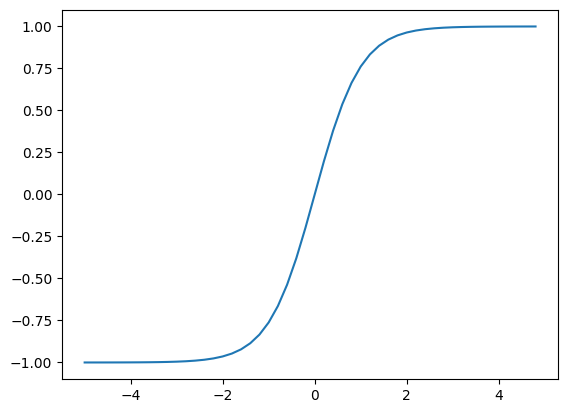

In [33]:
xs = np.arange(-5, 5, 0.2)
sns.lineplot(x=xs, y=np.tanh(xs))

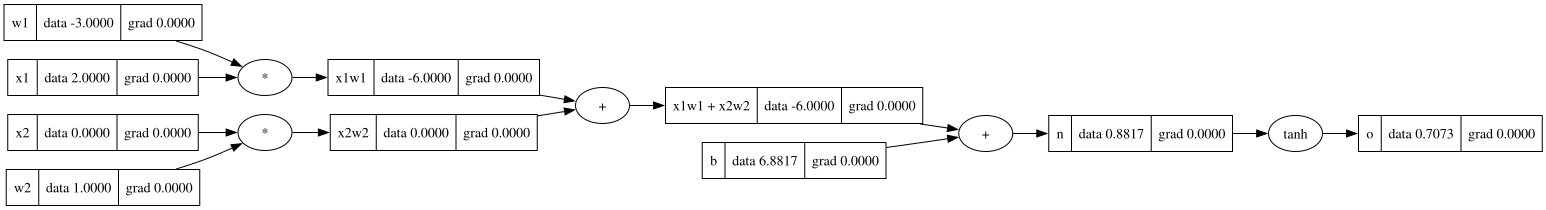

In [81]:
x1 = x2 = w1 = w2 = b = x1w1 = x2w2 = x1w1x2w2 = n = o = 0

def set_input():
    global x1, x2, w1, w2, b, x1w1, x2w2, x1w1x2w2, n, o
    # inputs
    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    
    # weights
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    
    # bias
    b = Value(6.881735, label='b')
    
    # product
    x1w1 = x1 * w1; x1w1.label = 'x1w1'
    x2w2 = x2 * w2; x2w2.label = 'x2w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
    
    # result neuron
    n = x1w1x2w2 + b; n.label = 'n'
    
    # output axon
    o = n.tanh(); o.label = 'o'

set_input()
draw_dot(o)

Now we can start backpropogation to fill in the gradients for each cell:

$$\frac{do}{dn} = 1 - o^2 = 0.5$$

We know addition operation simply distributes the gradient:
$$\frac{do}{d(x_1w_1 + x_2w_2)} = \frac{do}{dn} = 0.5$$
$$\frac{do}{db} = \frac{do}{dn} = 0.5$$

Similarly:
$$\frac{do}{d(x_1w_1)} = 0.5$$
$$\frac{do}{d(x_2w_2)} = 0.5$$

Finally:
$$\frac{do}{dx_1} = \frac{do}{d(x_1w_1)} * \frac{d(x_1w_1)}{dx_1} = 0.5 * -3.0 = -1.5$$
$$\frac{do}{dx_2} = \frac{do}{d(x_2w_2)} * \frac{d(x_2w_2)}{dx_2} = 0.5 * 1.0 = 0.5$$
$$\frac{do}{dw_1} = \frac{do}{d(x_1w_1)} * \frac{d(x_1w_1)}{dw_1} = 0.5 * 2.0 = 1.0$$
$$\frac{do}{dw_2} = \frac{do}{d(x_2w_2)} * \frac{d(x_2w_2)}{dw_2} = 0.5 * 0.0 = 0.0$$

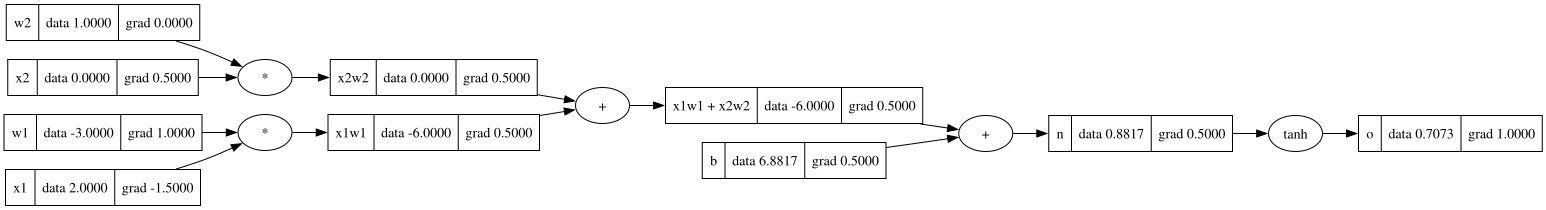

In [47]:
o.grad = 1.0 # derivative with itself is always 1
n.grad = x1w1x2w2.grad = b.grad = x1w1.grad = x2w2.grad = 0.5
x1.grad = w1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad

draw_dot(o)

Or using the backward propagation function:

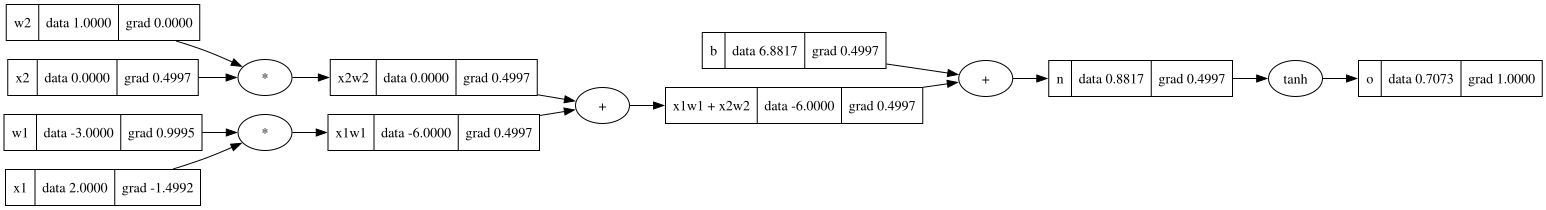

In [166]:
set_input()

# backward propogation            
o.backward()

draw_dot(o)

Looking at the gradients, if we want to increase the output axon value, we can either increase $x_2$, $w_1$, or decrease $x_1$.

## 4. Building a Neural Network

Now let's build a neural network with `Value`. 

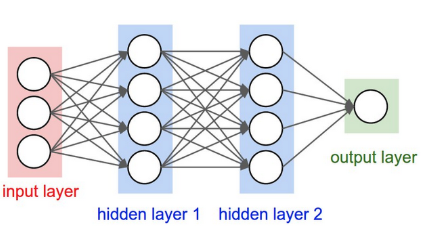

In [238]:
from IPython.display import Image
Image('neuron.png')

In [659]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []
        
class Neuron(Module):
    def __init__(self, nin): # takes n inputs
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # call is when a value is passed into an instance as argument, i.e. n(x) where n is a Neuron
        # here x is an array of numbers, i.e. the inputs
        # we want to calculate w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) # second param is the value you add to at the start
        out = act.tanh()
        return out 

    def parameters(self):
        return self.w + [self.b]

class Layer(Module):
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP(Module): # multi-layer perceptron
    def __init__(self, nin, nouts): # nouts is a list that defines the sizes of all layers we want
        size = [nin] + nouts
        self.layers = [Layer(size[i], size[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        # call each layer sequentially
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

Reinvent the neural network above:

In [664]:
x = [2.0, 3.0, -1.0] # input values
model = MLP(3, [4, 4, 1]) # 2 input layers with 4 neurons, one output layer with one neuron
model(x)

Value(data=-0.9019752337091569)

Now let's look at another example. In the example below, `xs` contains four different inputs to the neural network, and `ys` contains the results we want each input to output.

In [661]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [665]:
# run a prediction 
ypred = [model(x) for x in xs]
ypred

[Value(data=-0.9019752337091569),
 Value(data=-0.8563476499439073),
 Value(data=-0.9039439869835307),
 Value(data=-0.8598971747904904)]

We see that the predictions are way off the target outputs. The trick used in deep learning to achieve this is to calculate a single number that measures the total performance of the neural network.

$\rightarrow$ The Loss

Below we implement the mean squared error loss, essentially the squared difference of the output and target values. This ensures that the more off we are, the greater the loss will be.

In [666]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.106590045749908)

The aim is then trying to minimize the loss. Calling `backward` would give us the gradients, which in turn tells us how we need to tweak the input values (up or down through the gradient) to decrease the loss. 

In [667]:
loss.backward()

Looking at the gradient of the weight of the _first input value_ in the _first neuron_ in the first hidden layer, we see the direction we have to adjust this data value in order to decrease the loss. 

In [668]:
model.layers[0].neurons[0].w[0].grad 

np.float64(-0.5215791204965127)

In [669]:
model.layers[0].neurons[0].w[0].data

0.19204046530320462

To adjust the data, we use **gradient descent**, meaning we always move in the opposite direction of the gradient to minimize the loss. 

If `p.grad = -0.5`, it means "as the value of `p` **increases**, the loss would **decrease** at the rate of 0.5", vise versa. Hence, multiplying by 0.01 preserves the direction, and += nudges the weight accordingly:
- Negative grad → += 0.01 * (-0.5) → weight goes down → loss increases
- Positive grad → += 0.01 * (0.5) → weight goes up → loss increases

However, since the aim is to minimize the loss, we actually want to do the opposite, meaning we should update each value by stepping in the **opposite** direction of its gradient. 

In [670]:
for p in model.parameters():
    p.data += 0.01 * -p.grad

In [671]:
model.layers[0].neurons[0].w[0].data

np.float64(0.19725625650816975)

Now going back to the prediction step, we can see the loss is slowing decreasing as we nudge the input values. 

Let's put the whole **evaluation → loss → backward → update → evaluation** steps together:

In [554]:
epoch = 10
training_rate = 0.01

In [757]:
for k in range(epoch):
    # forward pass 
    ypred = [model(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # reset grad
    model.zero_grad()
        
    # backward pass
    loss.backward()

    # gradient descent
    for p in model.parameters():
        p.data += training_rate * -p.grad

    epoch_width = len(str(epoch))
    print(f"epoch {k+1:{epoch_width}}/{epoch} | loss: {loss.data:.4f}")

print(f"\nypred: {[round(y.data, 4) for y in ypred]}")

epoch  1/10 | loss: 0.0059
epoch  2/10 | loss: 0.0059
epoch  3/10 | loss: 0.0059
epoch  4/10 | loss: 0.0058
epoch  5/10 | loss: 0.0058
epoch  6/10 | loss: 0.0058
epoch  7/10 | loss: 0.0058
epoch  8/10 | loss: 0.0058
epoch  9/10 | loss: 0.0058
epoch 10/10 | loss: 0.0058

ypred: [np.float64(0.9639), np.float64(-0.9571), np.float64(-0.9692), np.float64(0.9588)]
